#   Data Analytics Project - การวิเคราะห์การต่อสัญญาการใช้บริการของลูกค้า

### Setup

In [1]:
%pip install pandas numpy seaborn matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data Collection

In [3]:
df = pd.read_csv("telco_cleaned.csv", encoding='UTF-8')

In [4]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,...,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,...,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,...,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,...,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6589 entries, 0 to 6588
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        6589 non-null   str    
 1   gender                             6589 non-null   str    
 2   age                                6589 non-null   int64  
 3   under_30                           6589 non-null   str    
 4   senior_citizen                     6589 non-null   str    
 5   married                            6589 non-null   str    
 6   dependents                         6589 non-null   str    
 7   number_of_dependents               6589 non-null   int64  
 8   city                               6589 non-null   str    
 9   zip_code                           6589 non-null   int64  
 10  population                         6589 non-null   int64  
 11  referred_a_friend                  6589 non-null   str    
 12  num

In [6]:
df.describe()

,age,number_of_dependents,zip_code,population,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,churn_score,cltv
count,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000
mean,46.760510,0.476097,93491.504477,22116.481105,2.020944,34.499772,23.004277,20.876461,66.228472,2432.042243,2.080938,7.169525,798.087251,3235.218082,3.194718,59.191228,4422.180756
std,16.841362,0.968499,1857.575392,21217.958517,3.024016,23.968734,15.466844,20.406247,29.907382,2265.500080,8.125054,25.803163,853.767972,2854.600036,1.207720,21.231782,1179.656518
min,19.000000,0.000000,90001.000000,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.850000,0.000000,0.000000,0.000000,21.610000,1.000000,5.000000,2003.000000
25%,33.000000,0.000000,92103.000000,2271.000000,0.000000,12.000000,9.250000,4.000000,40.550000,544.550000,0.000000,0.000000,106.680000,835.450000,3.000000,41.000000,3513.000000
50%,46.000000,0.000000,93526.000000,17372.000000,0.000000,32.000000,22.920000,17.000000,72.850000,1563.900000,0.000000,0.000000,472.680000,2376.450000,3.000000,63.000000,4552.000000
75%,60.000000,0.000000,95333.000000,36149.000000,3.000000,57.000000,36.440000,27.000000,90.600000,4003.000000,0.000000,0.000000,1275.120000,5106.640000,4.000000,76.000000,5393.000000
max,80.000000,9.000000,96150.000000,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


### Data Cleaning

### Data Processing

In [7]:
df.head(5)

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,...,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,...,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,...,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,...,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793


In [8]:
a = df['city'].unique()
for i in a :
    print(i)

Los Angeles
Inglewood
Whittier
Pico Rivera
Los Alamitos
Sierra Madre
Pasadena
North Hollywood
Covina
El Monte
La Puente
Rowland Heights
Ontario
Alpine
San Diego
Thermal
Riverside
Hemet
Moreno Valley
Perris
Anaheim
Brea
Yorba Linda
Summerland
Santa Barbara
Alpaugh
Camp Nelson
Delano
Fellows
Temecula
Biola
Selma
Squaw Valley
Fresno
Jolon
San Francisco
Palo Alto
Birds Landing
Byron
Fremont
Livermore
Napa
Pleasanton
San Ramon
Berkeley
Greenbrae
Forest Knolls
Freedom
Gilroy
Los Gatos
San Jose
Glencoe
Columbia
Escondido
Lakewood
Fulton
Nice
Alderpoint
Bayside
Loleta
Rio Dell
Davis
Folsom
Madison
Pleasant Grove
Sheridan
Wheatland
Rancho Cordova
Canyon Dam
Dobbins
Forest Ranch
Grass Valley
Nevada City
Fallbrook
Lewiston
Palo Cedro
Round Mountain
Hermosa Beach
Buena Park
Long Beach
South Pasadena
Glendale
Reseda
Sylmar
Burbank
Chino
Claremont
Desert Center
Wrightwood
Murrieta
Nuevo
Irvine
Corona Del Mar
Midway City
Newport Beach
Santa Ana
Oak View
Terra Bella
Bradley
Nipomo
Lee Vining
Palmdale


##### Ordinal Encoding

columns: under_30, senior_citizen, married, dependents, referred_a_friend, phone_service, multiple_lines, internet_service, online_security, online_backup, 
         device_protection_plan, premium_tech_support, streaming_tv, streaming_movies, streaming_music, unlimited_data, paperless_billing, churn_label

In [9]:
select_columns = ['under_30', 'senior_citizen', 'married', 'dependents', 'referred_a_friend', 
                  'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 
                  'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 
                  'unlimited_data', 'paperless_billing', 'churn_label']
oe_df = pd.DataFrame()
for i in select_columns:
    oe_df[i + '_oe'] = df[i].str.strip().str.lower().map({'yes': 1, 'no': 0})
oe_df.head()

,under_30_oe,senior_citizen_oe,married_oe,dependents_oe,referred_a_friend_oe,phone_service_oe,multiple_lines_oe,internet_service_oe,online_security_oe,online_backup_oe,device_protection_plan_oe,premium_tech_support_oe,streaming_tv_oe,streaming_movies_oe,streaming_music_oe,unlimited_data_oe,paperless_billing_oe,churn_label_oe
0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1
1,0,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1
2,0,1,0,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1
3,0,1,1,1,1,1,0,1,0,1,1,0,1,1,0,1,1,1
4,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1


##### One-Hot Encoding (ONE)

columns : gender, offer, internet_type, contract, payment_method, customer_status

In [10]:
# gender_df = pd.concat([df['gender'], pd.get_dummies(df['gender'], dtype=int)], axis=1)
gender_df = pd.concat([pd.get_dummies(df['gender'], dtype=int)], axis=1)
gender_df.head()

,Female,Male
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [11]:
# offer_df = pd.concat([df['offer'], pd.get_dummies(df['offer'], dtype=int)], axis=1)
offer_df = pd.concat([pd.get_dummies(df['offer'], dtype=int)], axis=1)
offer_df.head()

,No Offer,Offer A,Offer B,Offer C,Offer D,Offer E
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,1,0
3,0,0,0,1,0,0
4,0,0,0,1,0,0


In [12]:
# internet_type_df = pd.concat([df['internet_type'], pd.get_dummies(df['internet_type'], dtype=int)], axis=1)
internet_type_df = pd.concat([pd.get_dummies(df['internet_type'], dtype=int)], axis=1)
internet_type_df.head()

,Cable,DSL,Fiber Optic,No Internet
0,0,1,0,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [13]:
# contract_df = pd.concat([df['contract'], pd.get_dummies(df['contract'], dtype=int)], axis=1)
contract_df = pd.concat([pd.get_dummies(df['contract'], dtype=int)], axis=1)
contract_df.head()

,Month-to-Month,One Year,Two Year
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [14]:
# payment_method_df = pd.concat([df['payment_method'], pd.get_dummies(df['payment_method'], dtype=int)], axis=1)
payment_method_df = pd.concat([pd.get_dummies(df['payment_method'], dtype=int)], axis=1)
payment_method_df.head()

,Bank Withdrawal,Credit Card,Mailed Check
0,1,0,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0


In [15]:
# customer_status_df = pd.concat([df['customer_status'], pd.get_dummies(df['customer_status'], dtype=int)], axis=1)
customer_status_df = pd.concat([pd.get_dummies(df['customer_status'], dtype=int)], axis=1)
customer_status_df.head()

,Churned,Stayed
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


##### Merge columns

In [16]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,...,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,...,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,...,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,...,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793


In [17]:
oe_df.head()

,under_30_oe,senior_citizen_oe,married_oe,dependents_oe,referred_a_friend_oe,phone_service_oe,multiple_lines_oe,internet_service_oe,online_security_oe,online_backup_oe,device_protection_plan_oe,premium_tech_support_oe,streaming_tv_oe,streaming_movies_oe,streaming_music_oe,unlimited_data_oe,paperless_billing_oe,churn_label_oe
0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1
1,0,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1
2,0,1,0,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1
3,0,1,1,1,1,1,0,1,0,1,1,0,1,1,0,1,1,1
4,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1


In [18]:
offer_df.head()

,No Offer,Offer A,Offer B,Offer C,Offer D,Offer E
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,1,0
3,0,0,0,1,0,0
4,0,0,0,1,0,0


In [19]:
gender_df.head()

,Female,Male
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [20]:
merge_df = pd.concat([df[['age', 'number_of_dependents', 'population', 'number_of_referrals', 'number_of_referrals'
                          ,'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
                          'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 
                          'total_revenue', 'satisfaction_score', 'churn_score', 'cltv']],
                      oe_df, offer_df, gender_df, internet_type_df,
                      contract_df, payment_method_df, customer_status_df],
                     axis=1)
merge_df.head()

,age,number_of_dependents,population,number_of_referrals,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,...,Fiber Optic,No Internet,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check,Churned,Stayed
0,78,0,68701,0,0,0.00,8,39.65,39.65,0.00,...,0,0,1,0,0,1,0,0,1,0
1,74,1,55668,1,1,48.85,17,80.65,633.30,0.00,...,1,0,1,0,0,0,1,0,1,0
2,71,3,47534,0,0,11.33,52,95.45,1752.55,45.61,...,1,0,1,0,0,1,0,0,1,0
3,78,1,27778,1,1,19.76,12,98.50,2514.50,13.43,...,1,0,1,0,0,1,0,0,1,0
4,80,1,26265,1,1,6.33,14,76.50,2868.15,0.00,...,1,0,1,0,0,1,0,0,1,0


In [21]:
merge_df = merge_df.loc[:, ~merge_df.columns.duplicated(keep='first')]
merge_df.head()

,age,number_of_dependents,population,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,...,Fiber Optic,No Internet,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check,Churned,Stayed
0,78,0,68701,0,0.00,8,39.65,39.65,0.00,20,...,0,0,1,0,0,1,0,0,1,0
1,74,1,55668,1,48.85,17,80.65,633.30,0.00,0,...,1,0,1,0,0,0,1,0,1,0
2,71,3,47534,0,11.33,52,95.45,1752.55,45.61,0,...,1,0,1,0,0,1,0,0,1,0
3,78,1,27778,1,19.76,12,98.50,2514.50,13.43,0,...,1,0,1,0,0,1,0,0,1,0
4,80,1,26265,1,6.33,14,76.50,2868.15,0.00,0,...,1,0,1,0,0,1,0,0,1,0


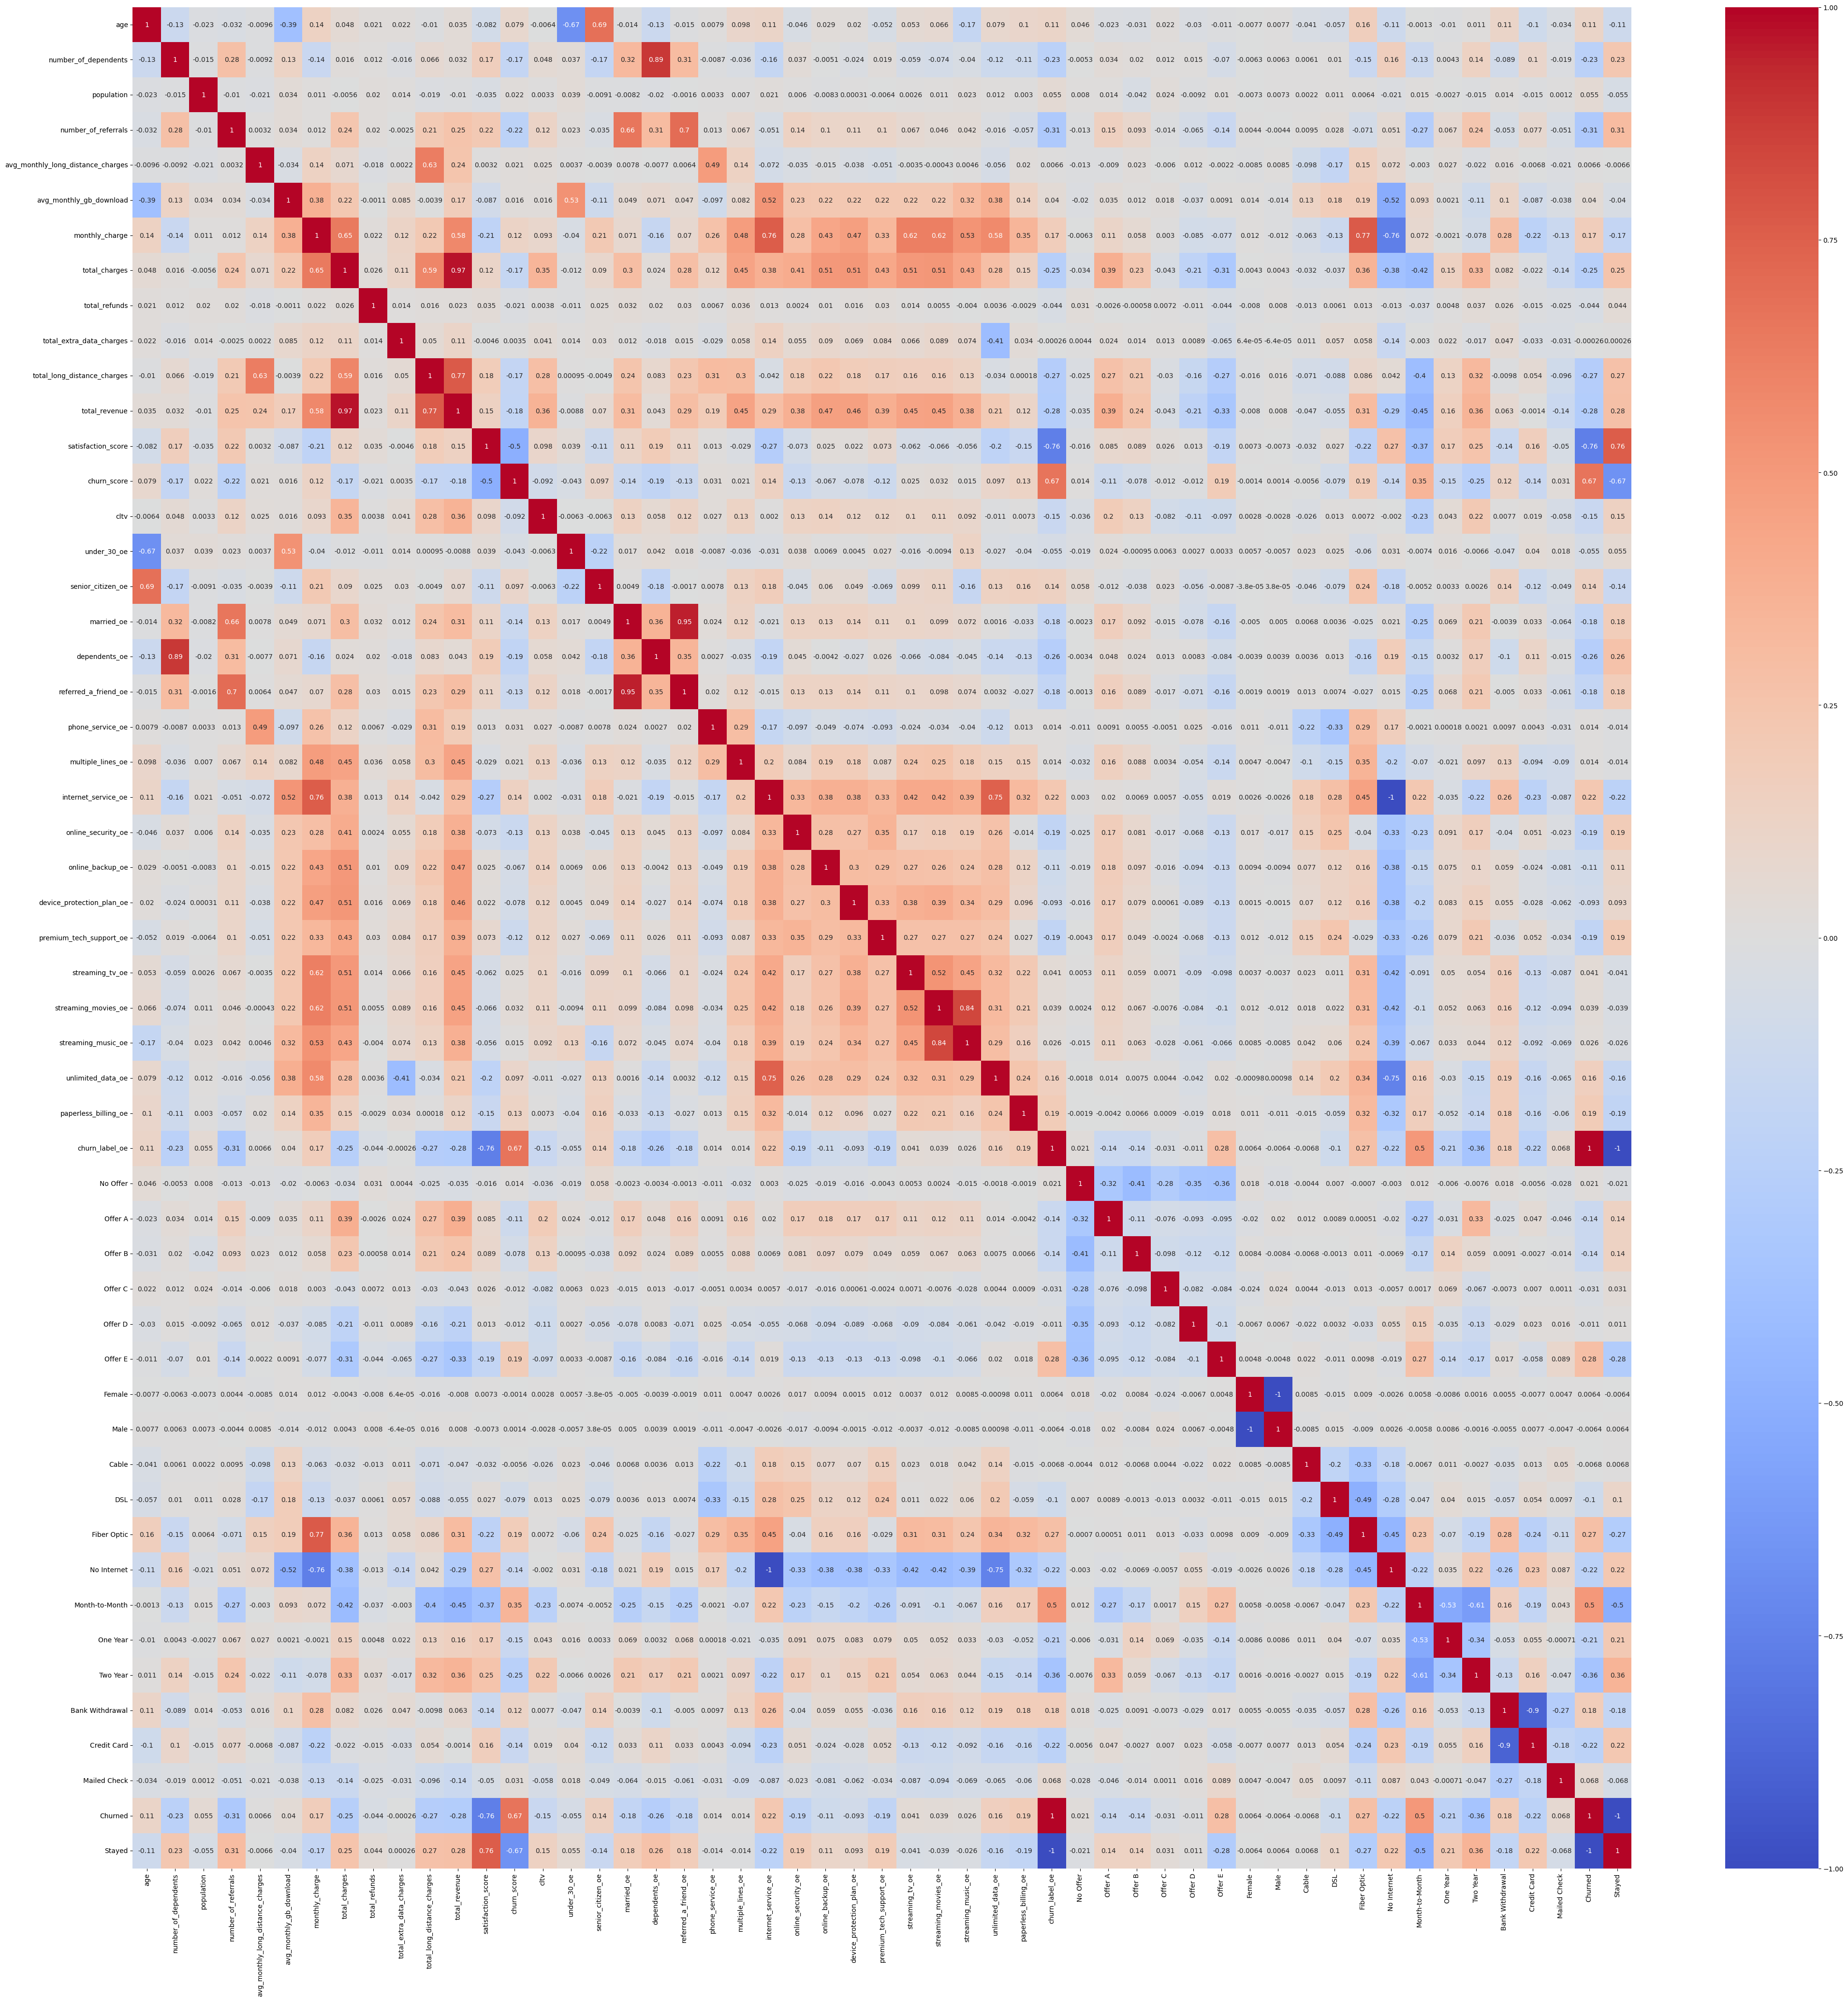

In [22]:
plt.figure(figsize=(50,50))
sns.heatmap(merge_df.corr(), cmap='coolwarm', annot=True)
plt.show()

### Data Exploration

In [23]:
sns.set(style="whitegrid")

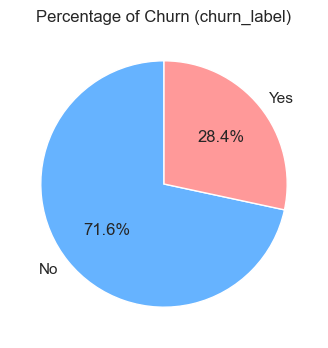

In [24]:
# สัดส่วนคนเลิกใช้บริการ (churn_label)
plt.figure(figsize=(6, 4))
churn_counts = df['churn_label'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Percentage of Churn (churn_label)')
plt.show()

# Insight: คนเลิกใช้สัญญา (Yes) มีน้อยกว่าคนอยู่ต่อ (No)

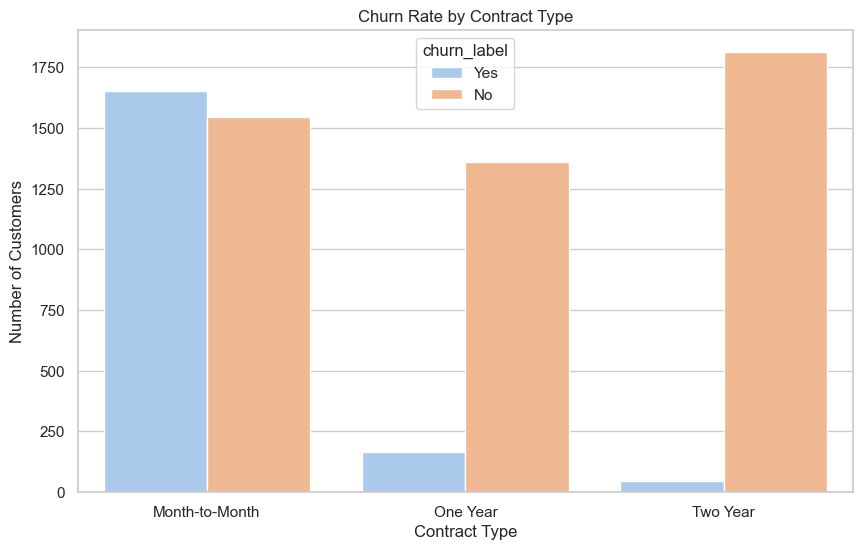

In [25]:
# วิเคราะห์การต่อสัญญา: ประเภทสัญญา กับ การเลิกใช้
plt.figure(figsize=(10, 6))
sns.countplot(x='contract', hue='churn_label', data=df, palette='pastel')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

#Insight: ลูกค้าแบบรายเดือน (Month-to-month) มีอัตราการยกเลิกสูง โดยที่สัญญา 2 ปี (Two year) แทบไม่มีการยกเลิกเลย

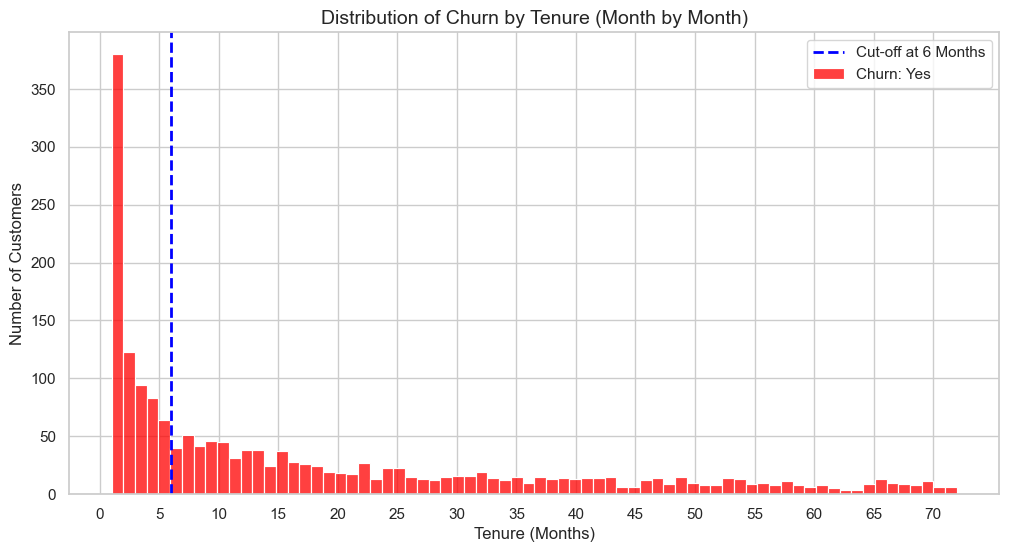

In [26]:
# วิเคราะห์ระยะเวลา: ระยะเวลาเป็นลูกค้า กับ การเลิกใช้
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(df[df['churn_label'] == 'Yes']['tenure_in_months'],
             bins=72, color='red', label='Churn: Yes')

plt.axvline(x=6, color='blue', linestyle='--', linewidth=2, label='Cut-off at 6 Months')

plt.xticks(range(0, 75, 5))

plt.title('Distribution of Churn by Tenure (Month by Month)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

# Insight: Early Churn สูงมากในช่วง 1-6 เดือนแรก ลูกค้าใหม่มีความเสี่ยงที่จะยกเลิกสัญญามากที่สุด

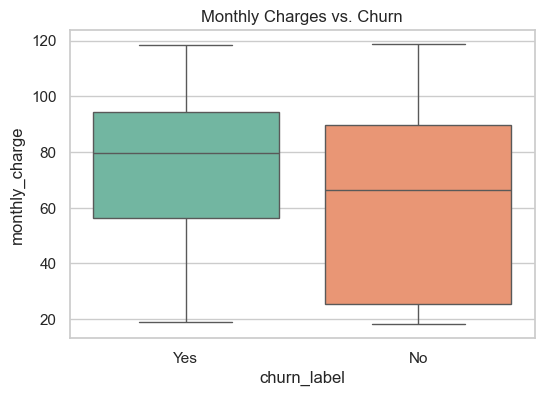

In [28]:
# Monthly Charges vs. Churn (ค่าบริการรายเดือน)
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn_label', y='monthly_charge', data=df, hue='churn_label', legend=False, palette='Set2')
plt.title('Monthly Charges vs. Churn')
plt.show()

# Insight: ลูกค้าที่ ยกเลิกสัญญา มียอดชำระรายเดือนเฉลี่ย สูงกว่า กลุ่มที่อยู่ต่อ

### Data Modeling

### Data Deployment